In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from iminuit import Minuit
import seaborn as sns
import matplotlib.patches as patches
from scipy import stats
import scipy.interpolate

In [9]:
def setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150):
    """
    Global plotting setup:
    - Seaborn grey background
    - Custom reversed/de-saturated deep palette
    - Serif + STIX math fonts
    - Grid, linewidths, ticks, figure defaults
    """

    # --- Base style (grey background preserved) ---
    plt.style.use("seaborn-v0_8")
    sns.set()
    sns.set_context("paper", font_scale=1.4)
    sns.set_style("ticks")

    # --- Color palette ---
    #colors = sns.color_palette("deep", 10, desat=0.8)
    #colors = sns.color_palette("husl", 10)
    #colors = sns.color_palette("tab10", 10)
    colors = sns.color_palette("Set1", 10)
    #colors = colors[::-1]
    #colors.pop(2)
    sns.set_palette(colors)

    # --- Fonts ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"] + plt.rcParams["font.serif"],
        "mathtext.fontset": "stix",
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    return colors


def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
    
colors = setup_plotting(ticksize=14, fontsize=16, figsize=(16, 9), dpi=150)

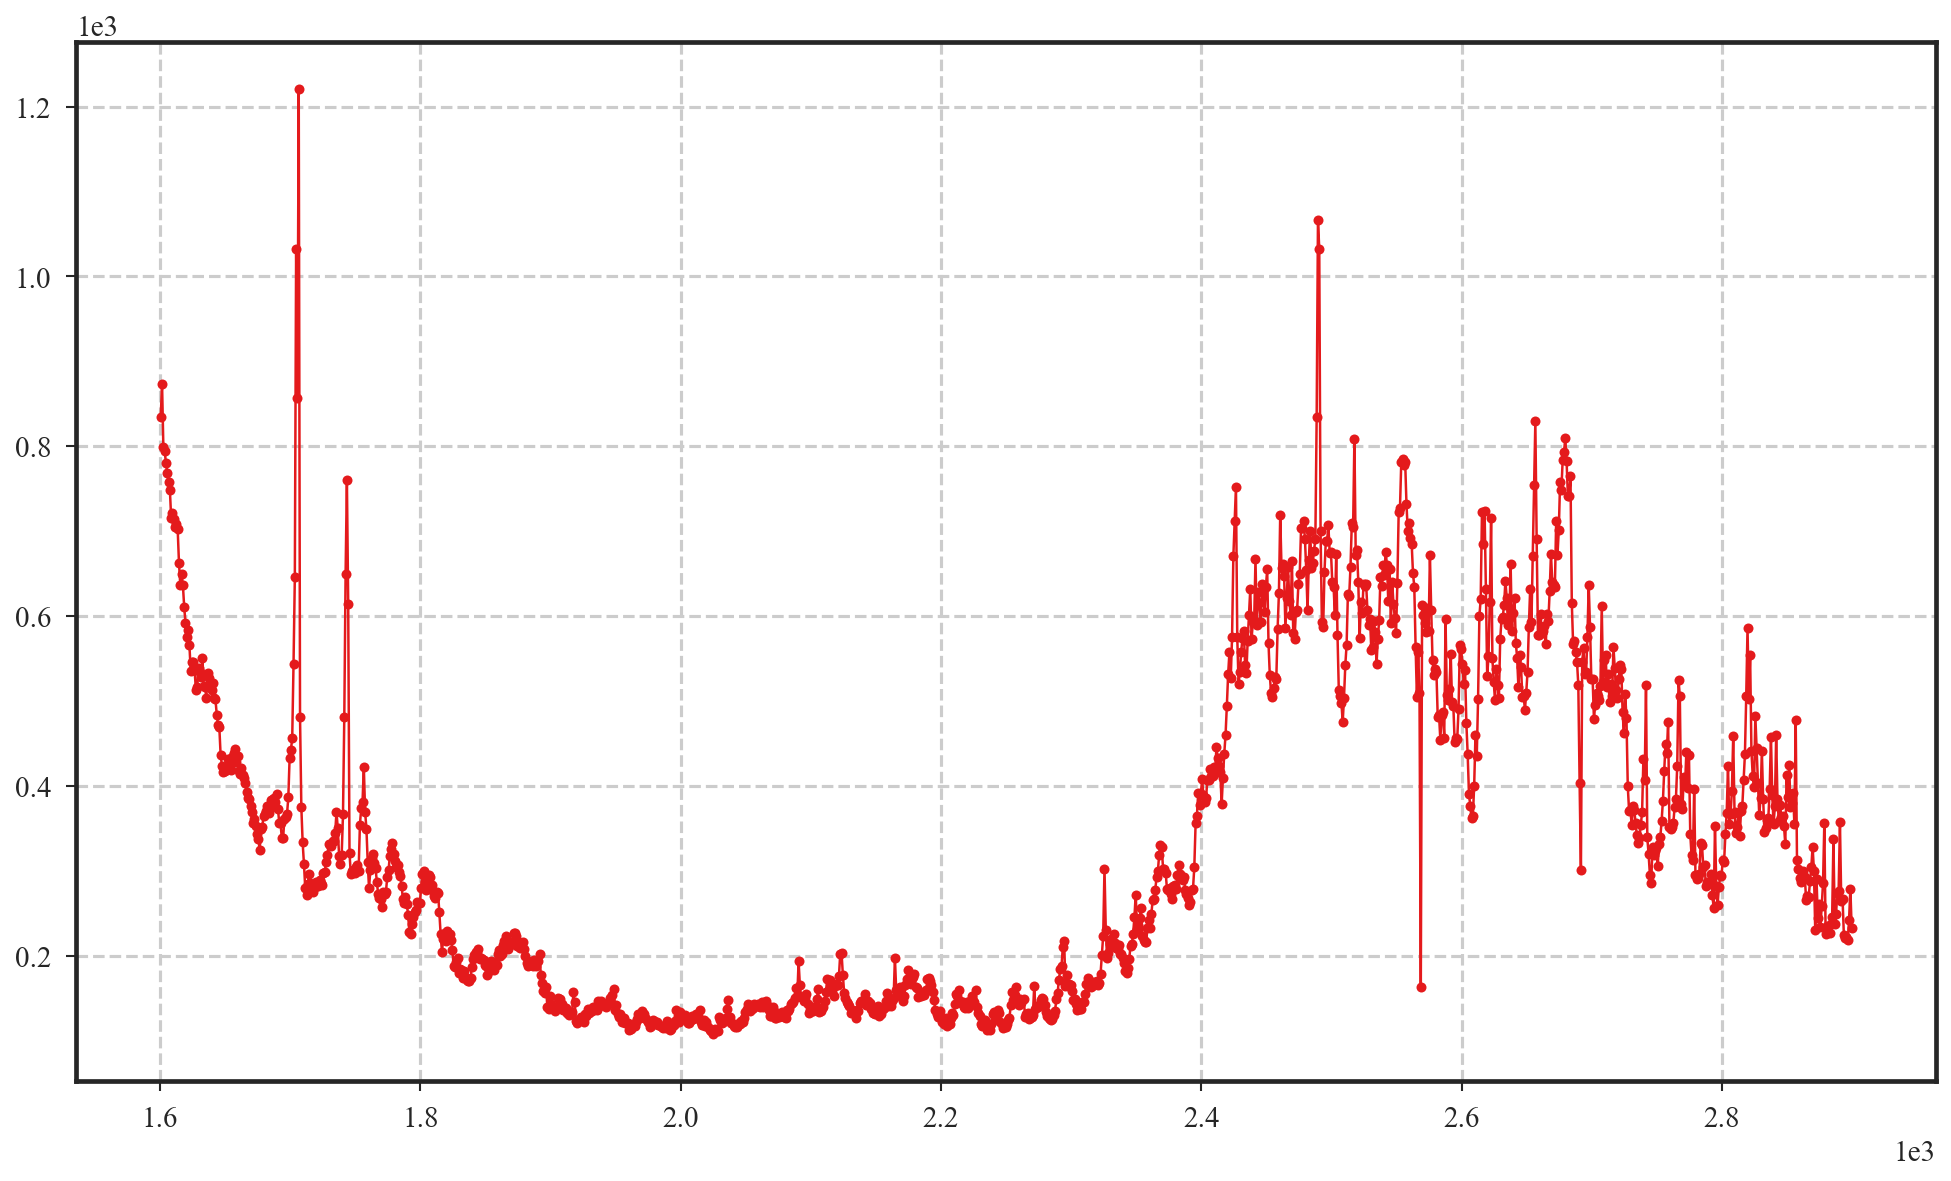

In [12]:
data = np.genfromtxt('DustLog_forClass.dat.txt')
depth = data[:, 0]
dust = data[:, 1]
plt.plot(depth, dust, marker='o', linestyle='-', color=colors[0], label='Depth vs Dust')

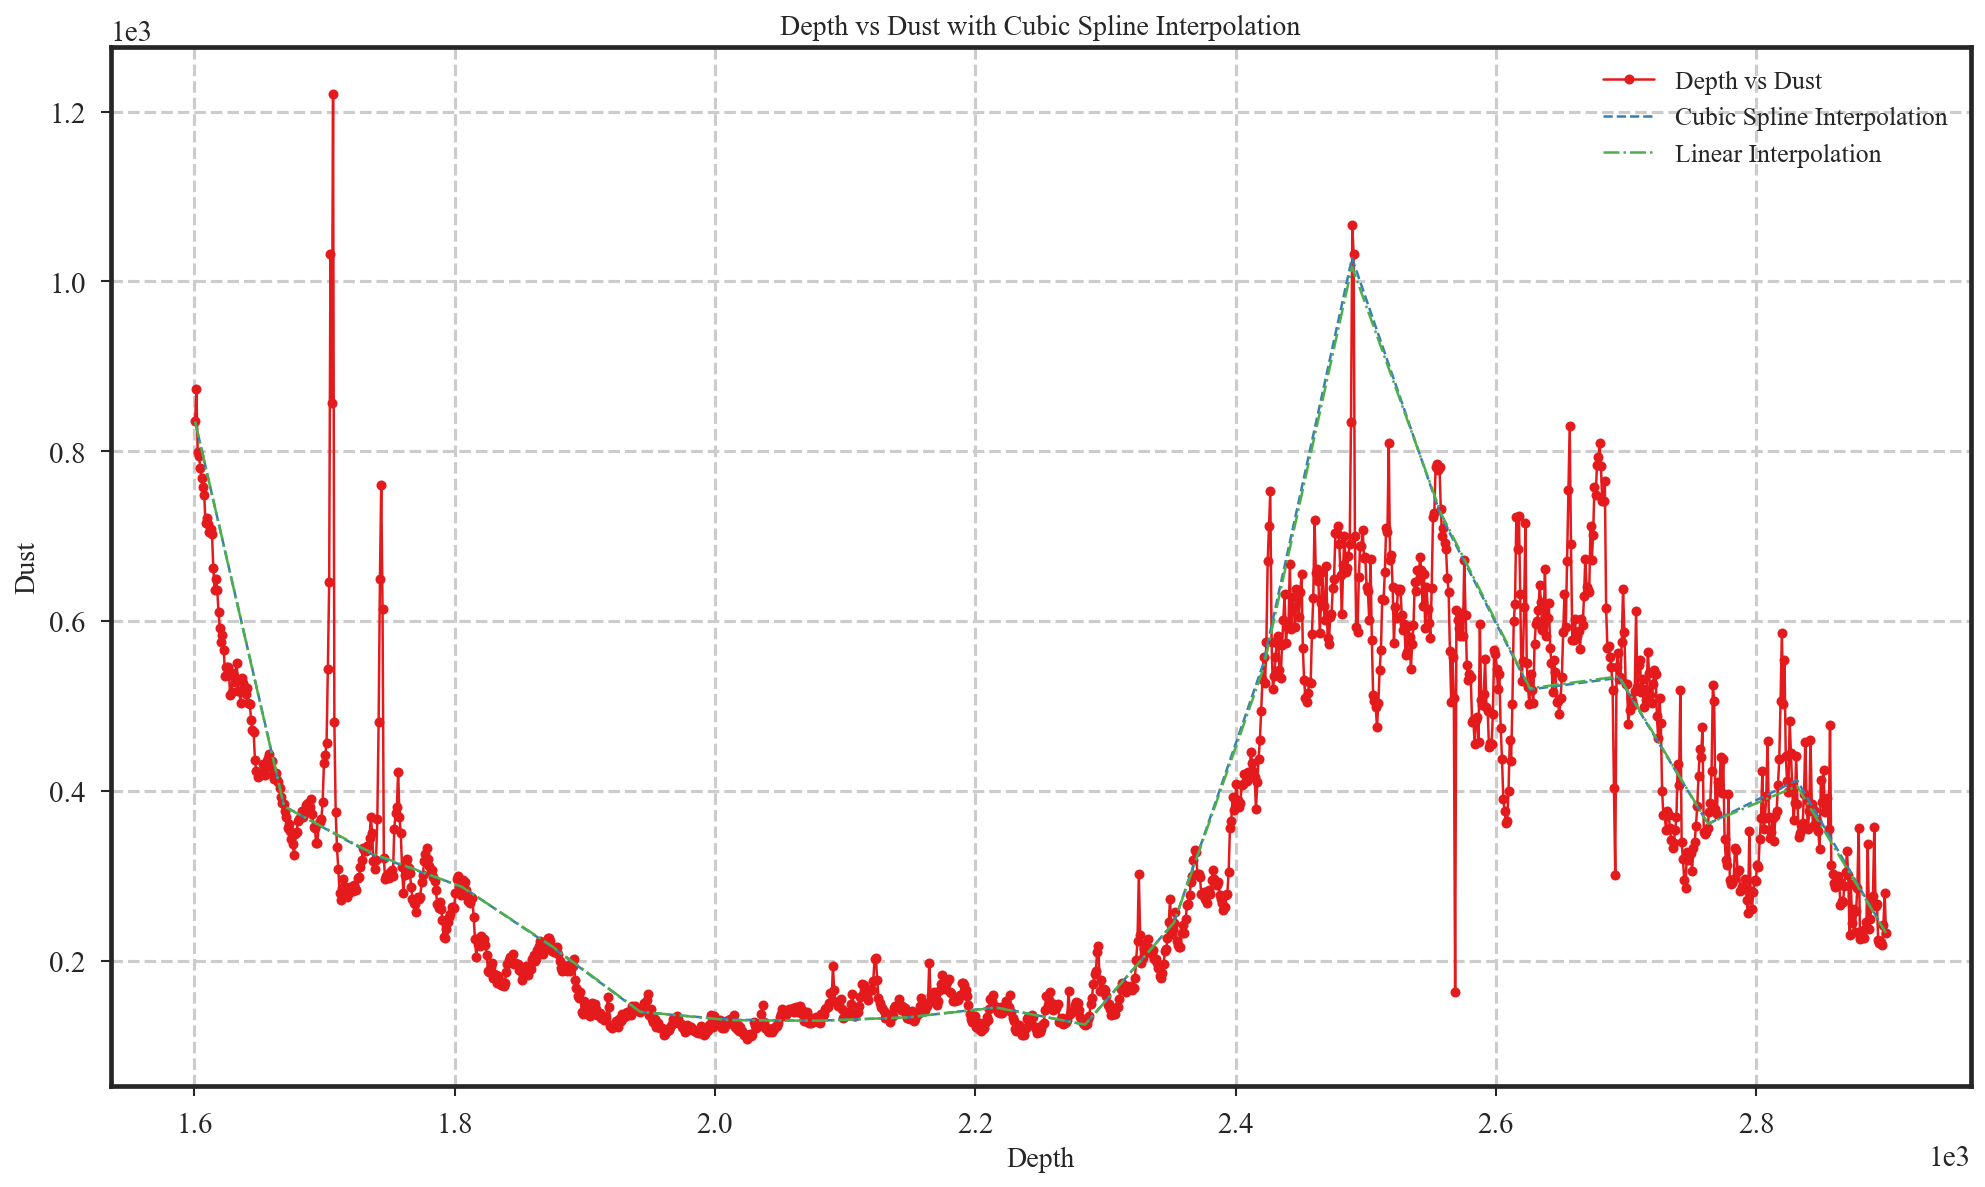

In [28]:
cubic_spline =scipy.interpolate.CubicSpline(depth, dust)
x_axis = np.linspace(depth.min(), depth.max(), 20)
plt.plot(depth, dust, marker='o', linestyle='-', color=colors[0], label='Depth vs Dust')
plt.plot(x_axis, cubic_spline(x_axis), linestyle='--', color=colors[1], label='Cubic Spline Interpolation')
linear_interp = scipy.interpolate.interp1d(depth, dust, kind='linear')
plt.plot(x_axis, linear_interp(x_axis), linestyle='-.', color=colors[2], label='Linear Interpolation')

plt.xlabel('Depth')
plt.ylabel('Dust')
plt.title('Depth vs Dust with Cubic Spline Interpolation')
plt.legend()
plt.show()

In [43]:
spline_data = np.genfromtxt('SplineCubic.txt')
x = spline_data[:, 0]
y = spline_data[:, 1]
#y = np.log(y)


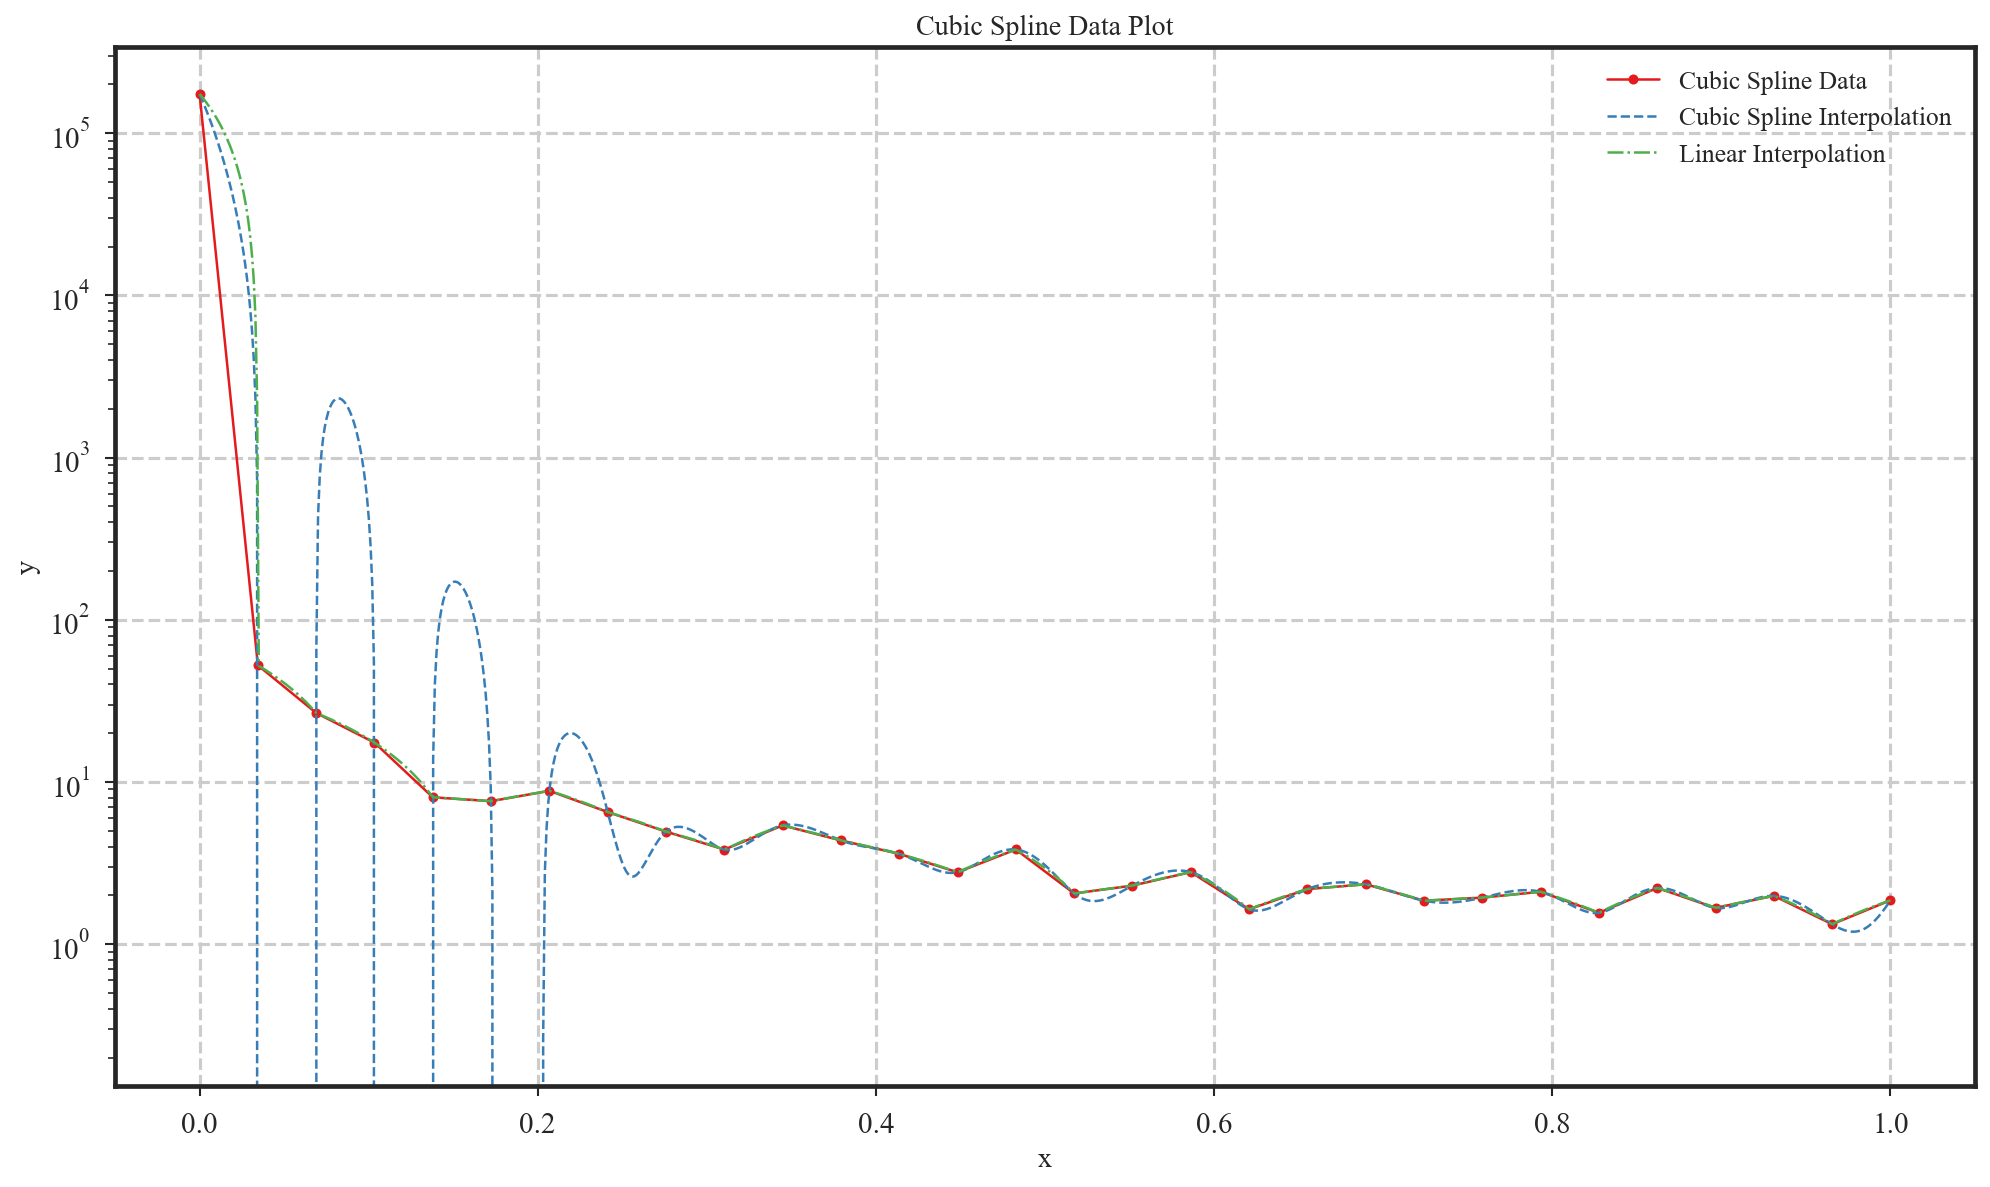

In [45]:
cubic_spline =scipy.interpolate.CubicSpline(x, y)
x_axis = np.linspace(x.min(), x.max(), 1000)
plt.plot(x, y, marker='o', linestyle='-', color=colors[0], label='Cubic Spline Data')
plt.plot(x_axis, cubic_spline(x_axis), linestyle='--', color=colors[1], label='Cubic Spline Interpolation')
linear_interp = scipy.interpolate.interp1d(x, y, kind='linear')
plt.plot(x_axis, linear_interp(x_axis), linestyle='-.', color=colors[2], label='Linear Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Cubic Spline Data Plot')
plt.yscale('log')
plt.legend()
plt.show()

In [46]:
integral, _ = integrate.quad(cubic_spline, 1e-5, 0.01)
print(f"Integral of cubic spline from 1e-5 to 0.01: {integral}")

Integral of cubic spline from 1e-5 to 0.01: 1313.2548778155265


In [47]:
integral, _ = integrate.quad(linear_interp, 1e-5, 0.01)
print(f"Integral of linear interpolation from 1e-5 to 0.01: {integral}")

Integral of linear interpolation from 1e-5 to 0.01: 1493.398282772383


In [48]:
integral, _ = integrate.quad(cubic_spline, 0.03, 0.1)
print(f"Integral of cubic spline from 0.03 to 0.1: {integral}")
integral, _ = integrate.quad(linear_interp, 0.03, 0.1)
print(f"Integral of linear interpolation from 0.03 to 0.1: {integral}")

Integral of cubic spline from 0.03 to 0.1: -115.92359623900542
Integral of linear interpolation from 0.03 to 0.1: 53.42664904677583
